## The Big Project begins!!

# ForecastLLM Capstone Project

This week - build a model that predicts future values from historical time-series data, adapting the original pricing workflow to forecasting

# Order of play

DAY 1: Data Curation  
DAY 2: Data Pre-processing  
DAY 3: Baselines and Evaluation  
DAY 4: Deep Learning and LLMs  
DAY 5: Fine-tuning a Frontier Model  

## DAY 1: Data Curation

Today we'll scrub our dataset and curate our data for forecasting.

In this adaptation, we prepare time-series data instead of pricing/product text data.


<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/business.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#181;">Business value of Data Curation</h2>
            <span style="color:#181;">Data Curation can be considered the less glamorous work of a Data Scientist. I say that's nonsense!
            This is where the science happens - what could be more glamorous than that?! R&D with your
            dataset can often have a greater impact on performance than the fashionable 'hyper-parameter optimization' that we do later.
            So: prepare for Quality Time with Data Quality.</span>
        </td>
    </tr>
</table>


In [1]:
# imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from importlib import import_module
from dotenv import load_dotenv

# replaced pricing dataset with time-series data
from week6.data_loader import load_sample_series


In [2]:
# replaced HuggingFace login with a quick reproducibility seed setup

load_dotenv()

np.random.seed(42)
random.seed(42)
print("Seeds set to 42")
print(f"FORECAST_DATA_PATH={os.getenv('FORECAST_DATA_PATH')}")

# optional tokenizer bootstrap for local smoke-test cells
BASE_MODEL = os.getenv("BASE_MODEL", "TinyLlama/TinyLlama-1.1B-Chat-v1.0")
tokenizer = None
try:
    transformers = import_module("transformers")
    AutoTokenizer = getattr(transformers, "AutoTokenizer", None)
    if AutoTokenizer is not None:
        tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
        print(f"Tokenizer loaded for smoke tests: {BASE_MODEL}")
except Exception as e:
    print(f"Tokenizer bootstrap skipped ({e})")


Seeds set to 42
FORECAST_DATA_PATH=/home/geo/Projects/Python/forecastllm/data/m4/processed/hourly_longest_series.csv
Tokenizer loaded for smoke tests: TinyLlama/TinyLlama-1.1B-Chat-v1.0


## Load our dataset

In the next cell, we load one M4 hourly series via `week6.data_loader.load_sample_series`.

Synthetic data is kept only as an explicit fallback (`USE_SYNTHETIC_FALLBACK=True`).


In [3]:
# Load one M4 hourly series via the shared loader
USE_SYNTHETIC_FALLBACK = False

try:
    ts_df = load_sample_series()
except Exception as e:
    if not USE_SYNTHETIC_FALLBACK:
        raise
    from week6.data_loader import load_synthetic_series
    print(f"Loader failed ({e}); using explicit synthetic fallback.")
    ts_df = load_synthetic_series(periods=240)

if not isinstance(ts_df, pd.DataFrame):
    raise TypeError(f"load_sample_series must return a pandas DataFrame, got {type(ts_df)}")
if not {"timestamp", "value"}.issubset(ts_df.columns):
    raise ValueError("Loaded dataframe must include 'timestamp' and 'value' columns")

ts_df = ts_df[["timestamp", "value"]].copy()
ts_df["timestamp"] = pd.to_datetime(ts_df["timestamp"], errors="coerce")
ts_df["value"] = pd.to_numeric(ts_df["value"], errors="coerce")
ts_df = ts_df.dropna(subset=["timestamp", "value"]).sort_values("timestamp").reset_index(drop=True)

if len(ts_df) < 30:
    raise RuntimeError(f"Need at least 30 usable rows, got {len(ts_df)}")

ts_df.head()

,timestamp,value
0,2000-01-01 00:00:00,12.8
1,2000-01-01 01:00:00,12.1
2,2000-01-01 02:00:00,11.6
3,2000-01-01 03:00:00,11.2
4,2000-01-01 04:00:00,10.8


In [4]:
print(f"Number of observations: {len(ts_df):,}")

Number of observations: 960


In [5]:
# Investigate a particular datapoint

probe_idx = min(6, len(ts_df) - 1)
ts_df.iloc[probe_idx]


timestamp    2000-01-01 06:00:00
value                       10.3
Name: 6, dtype: object

In [6]:
# What's the highest observed value?

max_idx = ts_df["value"].idxmax()
max_row = ts_df.loc[max_idx]
print(f"The highest value is {max_row['value']:.3f} at {max_row['timestamp']}")


The highest value is 26.300 at 2000-02-09 15:00:00


For forecasting, this helps us quickly sanity-check spikes and potential outliers before modeling.


In [7]:
# replaced Item parsing with time-series cleaning
# keep rows with numeric value and drop missing values

ts_df["value"] = pd.to_numeric(ts_df["value"], errors="coerce")
ts_df = ts_df.dropna(subset=["value"]).copy()
ts_df = ts_df.sort_values("timestamp").reset_index(drop=True)

# enforce minimum history length for forecasting
MIN_LENGTH = 30
if len(ts_df) < MIN_LENGTH:
    raise ValueError(f"Need at least {MIN_LENGTH} observations, found {len(ts_df)}")

print(f"There are {len(ts_df):,} usable observations after cleaning")


There are 960 usable observations after cleaning


In [8]:
ts_df.head(1)

,timestamp,value
0,2000-01-01,12.8


In [9]:
print(ts_df.head(10).to_string(index=False))

          timestamp  value
2000-01-01 00:00:00   12.8
2000-01-01 01:00:00   12.1
2000-01-01 02:00:00   11.6
2000-01-01 03:00:00   11.2
2000-01-01 04:00:00   10.8
2000-01-01 05:00:00   10.4
2000-01-01 06:00:00   10.3
2000-01-01 07:00:00   11.4
2000-01-01 08:00:00   13.1
2000-01-01 09:00:00   14.6


In [10]:
values = ts_df["value"].to_list()
window = 7
rolling = ts_df["value"].rolling(window=window).mean().to_list()

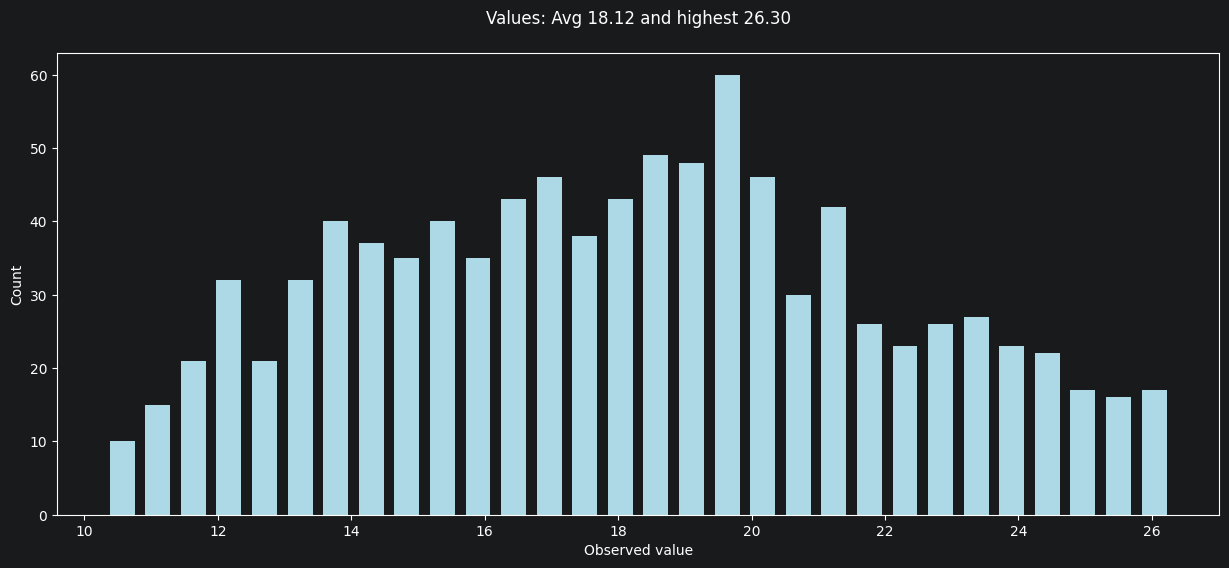

In [11]:
# Plot the distribution of values

plt.figure(figsize=(15, 6))
plt.title(f"Values: Avg {np.mean(values):,.2f} and highest {np.max(values):,.2f}\n")
plt.xlabel('Observed value')
plt.ylabel('Count')
plt.hist(values, rwidth=0.7, color="lightblue", bins=30)
plt.show()


In [12]:
max_value = np.max(values)
max_value_row = ts_df.iloc[int(np.argmax(values))]
print(max_value_row.to_string())


timestamp    2000-02-09 15:00:00
value                       26.3


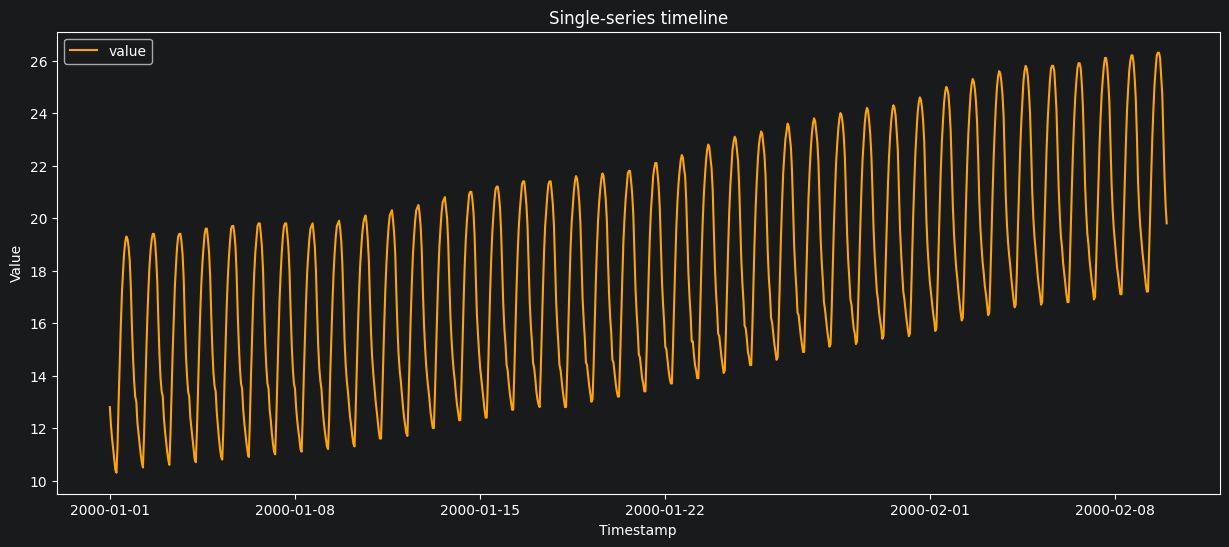

In [13]:
# Plot the time series
plt.figure(figsize=(15, 6))
plt.plot(ts_df["timestamp"], ts_df["value"], color="orange", label="value")
plt.title("Single-series timeline")
plt.xlabel("Timestamp")
plt.ylabel("Value")
plt.legend()
plt.show()


In [14]:
print(ts_df.tail(10).to_string(index=False))

          timestamp  value
2000-02-09 14:00:00   26.2
2000-02-09 15:00:00   26.3
2000-02-09 16:00:00   26.3
2000-02-09 17:00:00   26.1
2000-02-09 18:00:00   25.4
2000-02-09 19:00:00   24.7
2000-02-09 20:00:00   23.2
2000-02-09 21:00:00   21.6
2000-02-09 22:00:00   20.5
2000-02-09 23:00:00   19.8


In [15]:
# Day 1 scope: use a single primary time series.
# Later days may extend this to multiple M4 series.
all_series = [ts_df.copy()]


For now, Day 1 uses one selected M4 hourly series. Multi-series work is deferred to later days.

In [16]:
# Placeholder step retained for structural parity with the original notebook
all_series = [s.copy() for s in all_series]


In [17]:
print(f"Day 1 currently has {len(all_series):,} primary series")

Day 1 currently has 1 primary series


In [18]:
all_series[0].head()

,timestamp,value
0,2000-01-01 00:00:00,12.8
1,2000-01-01 01:00:00,12.1
2,2000-01-01 02:00:00,11.6
3,2000-01-01 03:00:00,11.2
4,2000-01-01 04:00:00,10.8


In [19]:
random.seed(42)
random.shuffle(all_series)

# Placeholder for future multi-series deduplication logic
seen = set()
deduped = []
for s in all_series:
    signature = tuple(np.round(s["value"].to_numpy(), 6))
    if signature not in seen:
        seen.add(signature)
        deduped.append(s)

all_series = deduped
print(f"After placeholder deduplication, we have {len(all_series):,} series")


After placeholder deduplication, we have 1 series


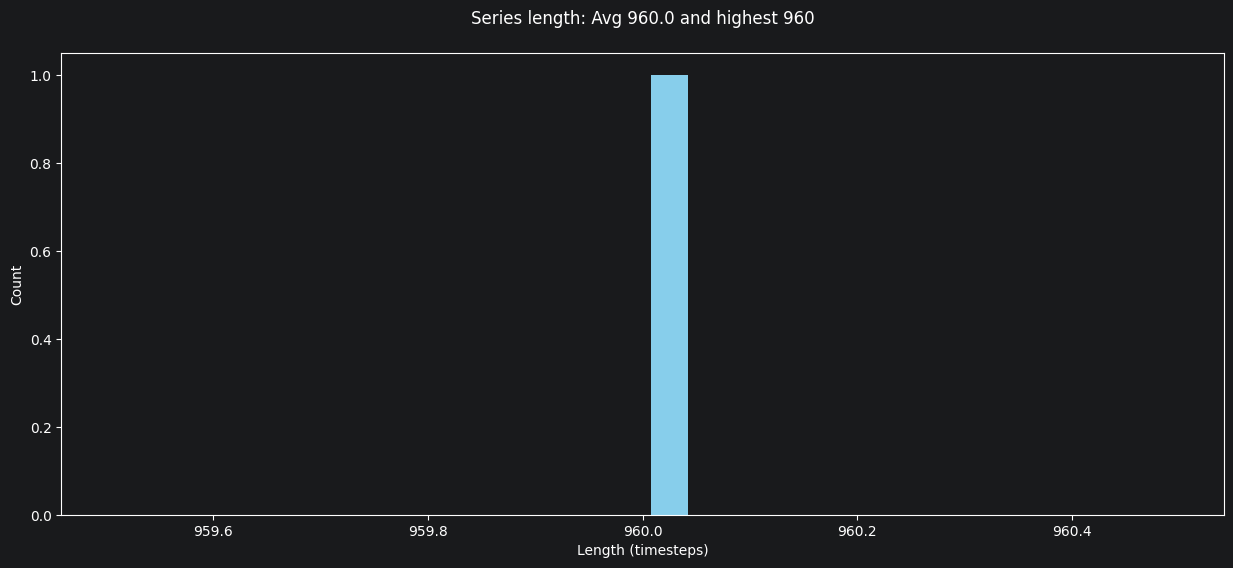

In [20]:
lengths = [len(s) for s in all_series]
plt.figure(figsize=(15, 6))
plt.title(f"Series length: Avg {np.mean(lengths):,.1f} and highest {np.max(lengths):,}\n")
plt.xlabel('Length (timesteps)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="skyblue", bins=20)
plt.show()


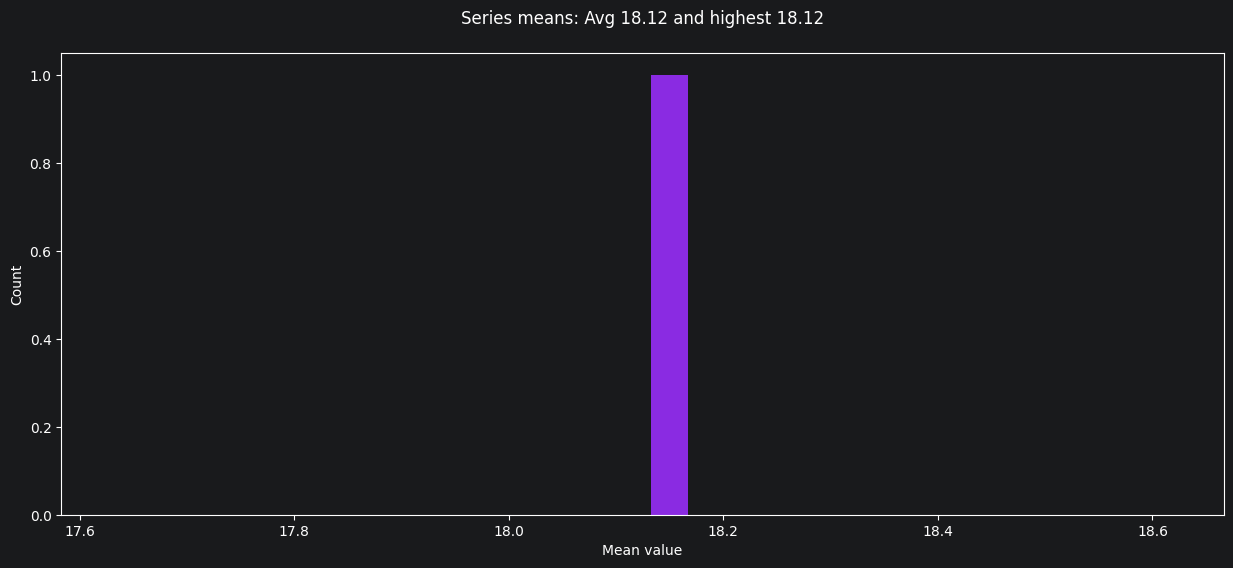

In [21]:
# Plot the distribution of average values across candidate series

series_means = [float(s["value"].mean()) for s in all_series]
plt.figure(figsize=(15, 6))
plt.title(f"Series means: Avg {np.mean(series_means):,.2f} and highest {np.max(series_means):,.2f}\n")
plt.xlabel('Mean value')
plt.ylabel('Count')
plt.hist(series_means, rwidth=0.7, color="blueviolet", bins=20)
plt.show()


In [22]:
# replaced category balancing with choosing usable series
np.random.seed(42)

SIZE = min(8, len(all_series))
series_lengths = np.array([len(s) for s in all_series], dtype=float)
weights = series_lengths / series_lengths.sum()
idx = np.random.choice(len(all_series), size=SIZE, replace=False, p=weights)
sample = [all_series[i] for i in idx]


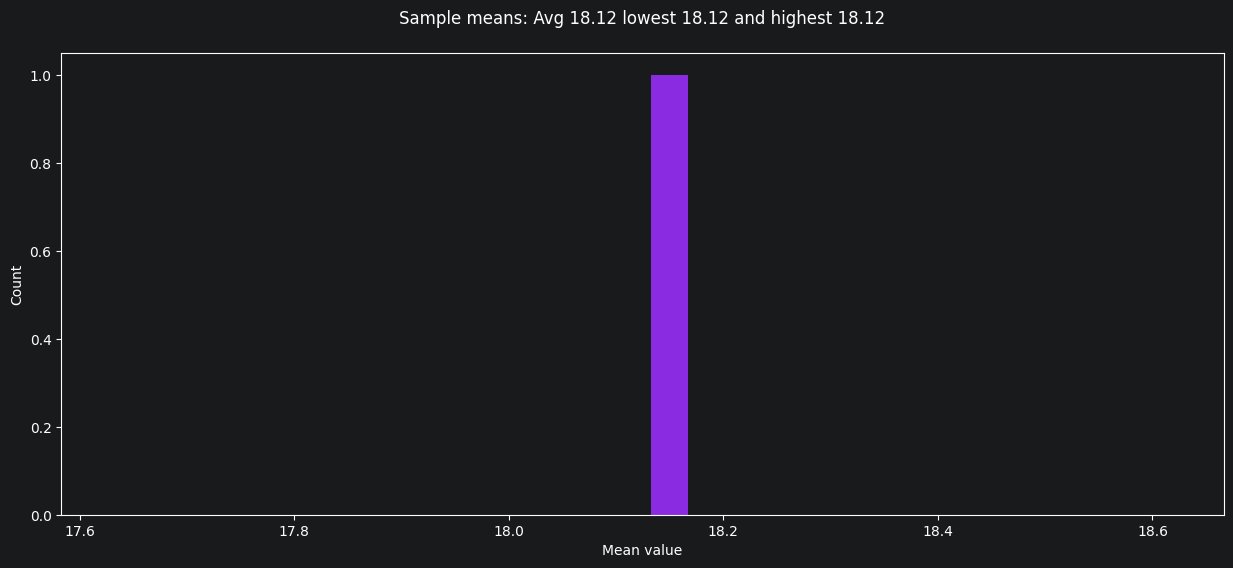

In [23]:
sample_means = [float(s["value"].mean()) for s in sample]
plt.figure(figsize=(15, 6))
plt.title(f"Sample means: Avg {np.mean(sample_means):,.2f} lowest {np.min(sample_means):,.2f} and highest {np.max(sample_means):,.2f}\n")
plt.xlabel('Mean value')
plt.ylabel('Count')
plt.hist(sample_means, rwidth=0.7, color="blueviolet", bins=20)
plt.show()


In [24]:
# Just for good measure, let's shuffle the sample again for the final dataset

random.seed(42)
random.shuffle(sample)


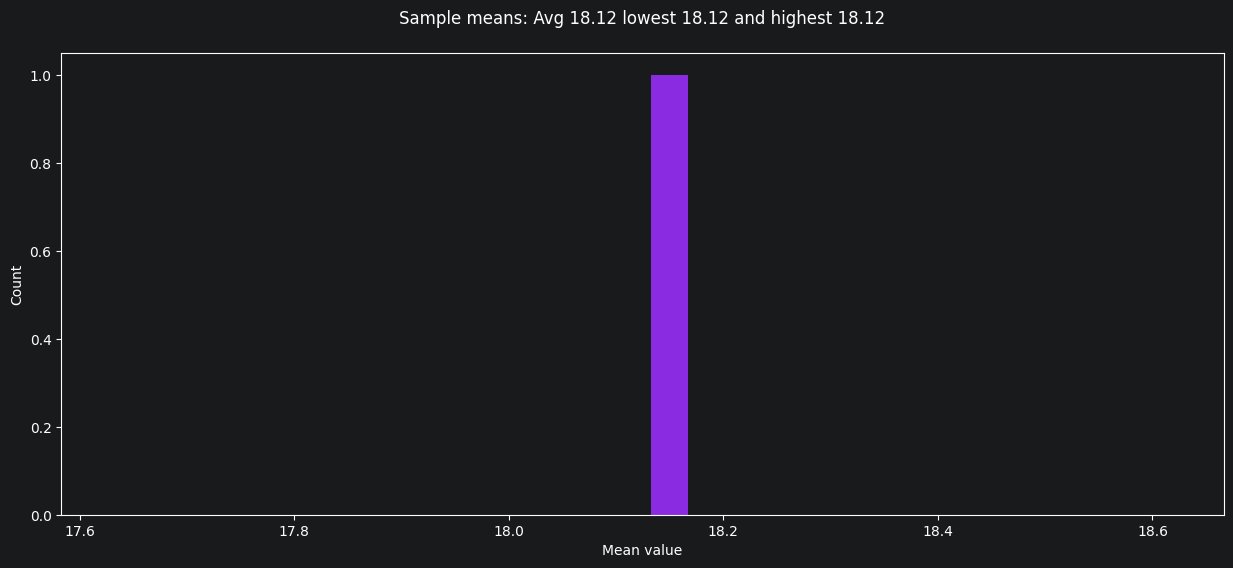

In [25]:
sample_means = [float(s["value"].mean()) for s in sample]
plt.figure(figsize=(15, 6))
plt.title(f"Sample means: Avg {np.mean(sample_means):,.2f} lowest {np.min(sample_means):,.2f} and highest {np.max(sample_means):,.2f}\n")
plt.xlabel('Mean value')
plt.ylabel('Count')
plt.hist(sample_means, rwidth=0.7, color="blueviolet", bins=20)
plt.show()


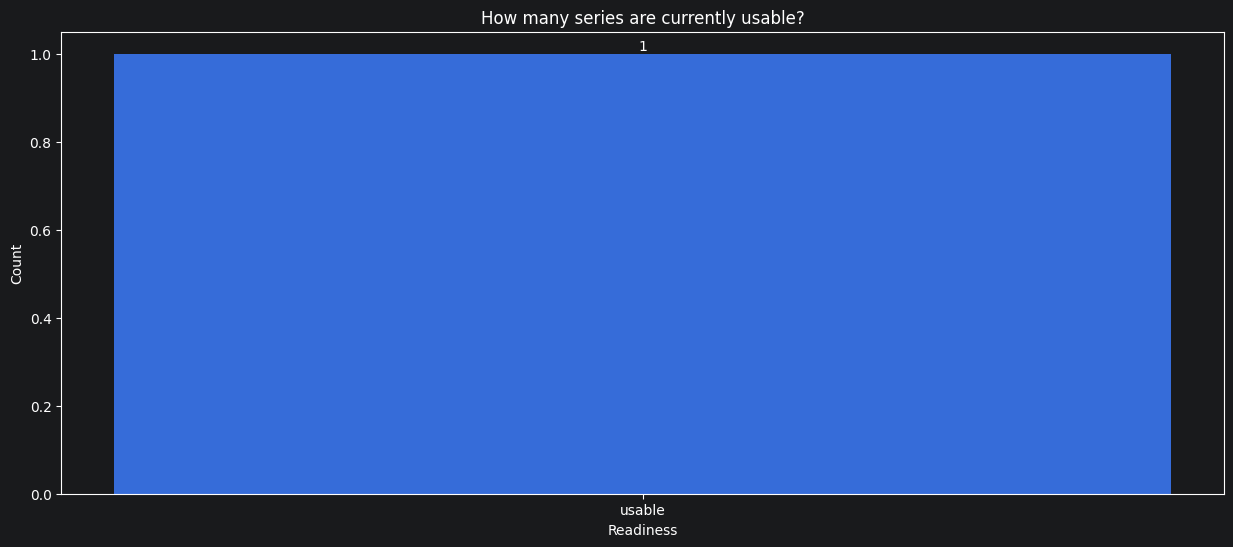

In [26]:
# replaced category counts with basic readiness flags
from collections import Counter

readiness = Counter(["usable" if len(s) >= MIN_LENGTH else "too_short" for s in sample])
labels = readiness.keys()
counts = [readiness[label] for label in labels]

plt.figure(figsize=(15, 6))
plt.bar(labels, counts)
plt.title('How many series are currently usable?')
plt.xlabel('Readiness')
plt.ylabel('Count')

for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.show()


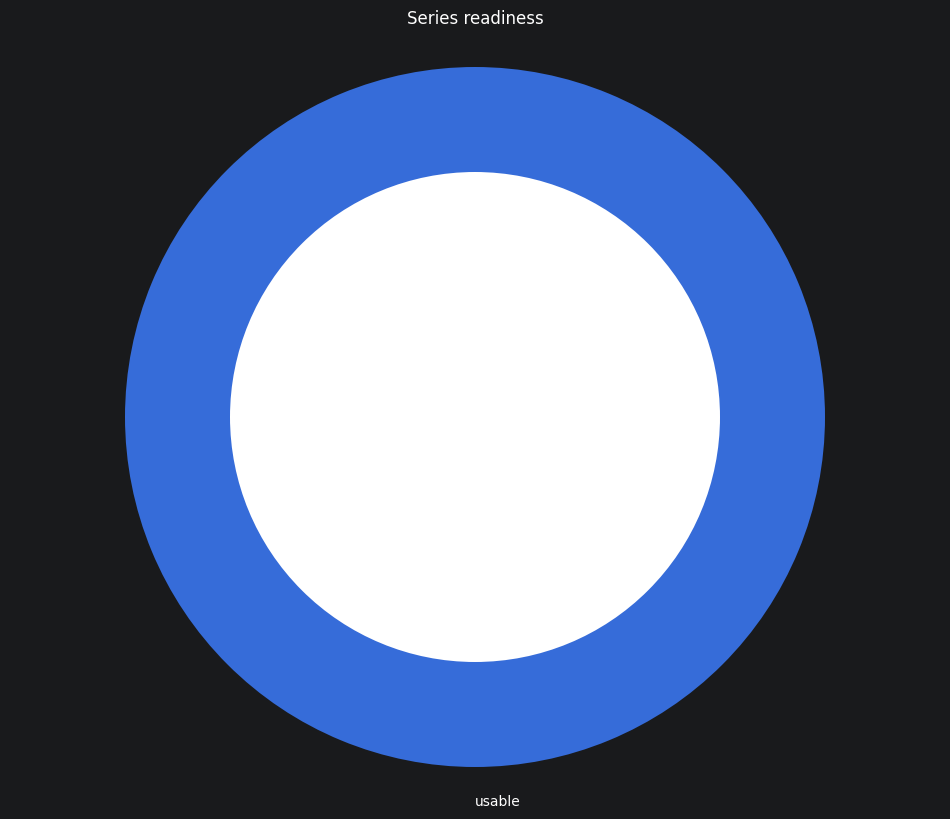

In [27]:
# Looking at the same readiness split as a donut chart

plt.figure(figsize=(12, 10))
plt.pie(counts, labels=labels, autopct='%1.0f%%', startangle=90)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Series readiness')
plt.axis('equal')

plt.show()


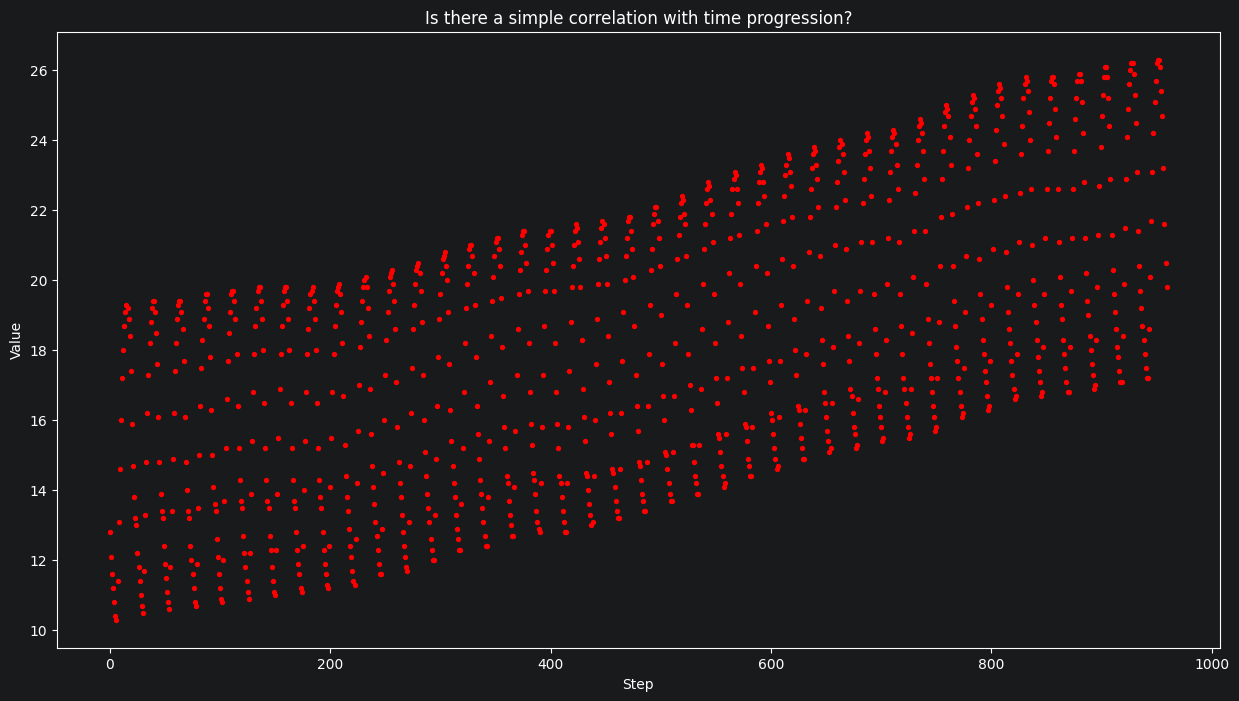

In [28]:
# How does the value vary with time index?

primary = sample[0].reset_index(drop=True).copy()
primary["step"] = np.arange(len(primary))

plt.figure(figsize=(15, 8))
plt.scatter(primary["step"], primary["value"], s=8, color="red")
plt.xlabel('Step')
plt.ylabel('Value')
plt.title('Is there a simple correlation with time progression?')
plt.show()


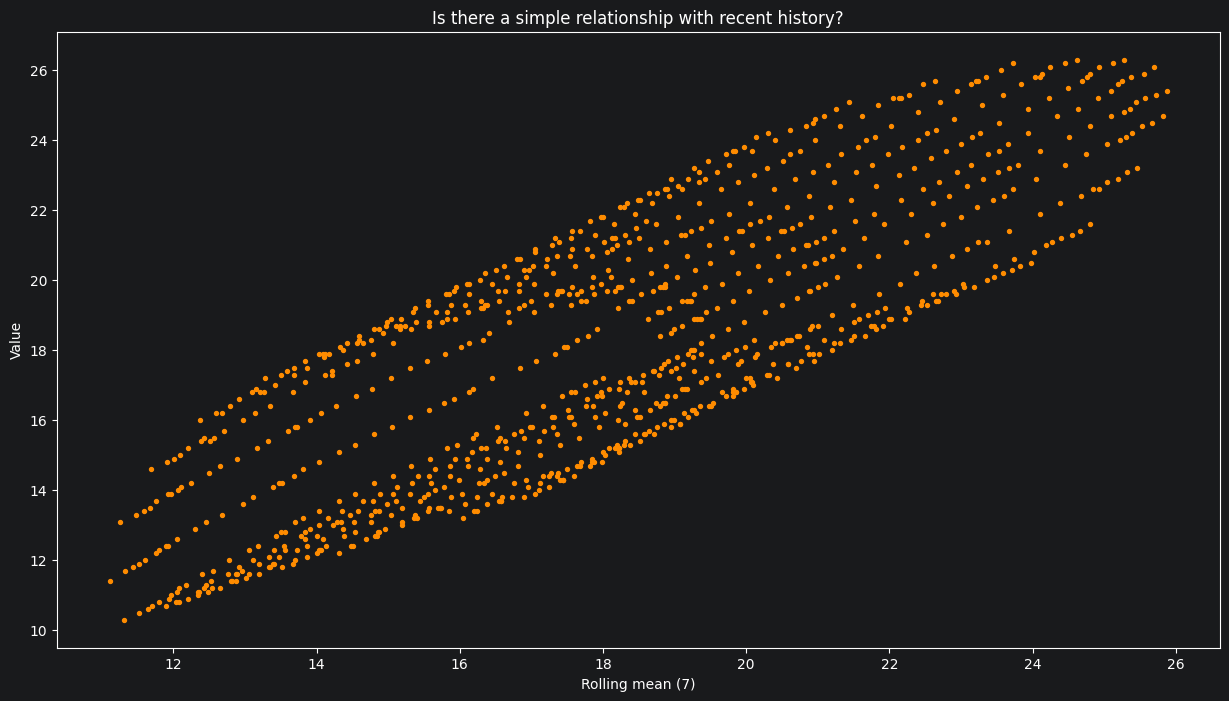

In [29]:
# How do value and rolling mean compare?

primary = primary.copy()
primary["rolling_7"] = primary["value"].rolling(7).mean()

plt.figure(figsize=(15, 8))
plt.scatter(primary["rolling_7"], primary["value"], s=8, color="darkorange")
plt.xlabel('Rolling mean (7)')
plt.ylabel('Value')
plt.title('Is there a simple relationship with recent history?')
plt.show()


## Packaging step (deferred)

In the original notebook, this section pushes the curated dataset to HuggingFace Hub.

For ForecastLLM Day 1, we defer publishing and keep the curated series local.


In [30]:
# TODO: replace this with forecasting dataset packaging/export when schema is finalized

forecast_horizon = 7
selected_series = sample[0].copy()

# simple train/validation/test split placeholder for upcoming days
train_end = int(len(selected_series) * 0.8)
val_end = int(len(selected_series) * 0.9)

train = selected_series.iloc[:train_end]
val = selected_series.iloc[train_end:val_end]
test = selected_series.iloc[val_end:]

print(f"Train rows: {len(train):,}, Val rows: {len(val):,}, Test rows: {len(test):,}")
print(f"Forecast horizon for this project: {forecast_horizon} steps")

# TODO: Day 3+ will add MAE and sMAPE evaluation logic


Train rows: 768, Val rows: 96, Test rows: 96
Forecast horizon for this project: 7 steps


Visualization details can be refined later.